<a href="https://colab.research.google.com/github/0xawasthi/ML-learning/blob/main/regression_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Intro to Machine Learning
**Machine Learning has two categories:**

- **Classification:** Its simply categorizing an unknown variable to a known state. That means, we will have a dataset along with categories as a training examples. Now our task would be, to classify any variable to one of the predefined categories, then we call it as a classification problem. Eg- cat vs dog classification, disease classification problem, face recognition system, vehicle number plate detection and classifier, etc..

- **Regression:** Its simply a prediction. When we have a numbers of data in a columns or strucutured data, and we need to predict based upon hisotorical dataset, then we call it as regression problem. E.g house prices prediction, stock marget prediction. That means anything related with prediction, we call it as regression problem

**Our task:**

A user wants to sell a car on an online classified website, and the site asks them to enter a price. If they dont know much the car is worth, they just need to guess. To those people or company, we want to help: How? the user describes the car, and our Machine learning model suggest the best prices.

**Question:** Which type of problem is this? Regression or Classification?

-> Regression

car:
- model
- km running
- condition
- numbers of hands
- resale
- parts avaialbity

To start any machine learning Model, here are the checklist:
-  dataset (https://www.kaggle.com/datasets/CooperUnion/cardataset)

for this project, lets collect the data from kaggle

## Implementation Guidelines:
**Our plan:**
To start this project, we will follow several steps:
- Get the data and do exploratory data analysis: Just look at the data and try learn more about data

- Prepare the dataset into train for linear regression model to predict price of the car

- Go into the details of how linear regression is implemented,

- Once you build the model, you need to evaluate the quality of your model with LR: RMSE. RMSE stands for root mean square error, a metric for evaluating quality of model prediction

- Do some feature engineering: The process of creating a new features, new characterisitcs that we can use for our model

- Deal with numerical stability problems and see how to solve them with regularization

- Finally, use that model

## Data Preparation

You need to work with data

In [2]:
import pandas as pd

In [3]:
url = '/content/drive/MyDrive/ML_datasets/car features data.csv'
df = pd.read_csv(url)

In [4]:
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [6]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

Problems identified
- looking at columns, there is some inconsistency, i.e sometime there are uppercase letter (Make, Model), sometimes,,there are spaces (Engine Fuel Type), sometime underscore (_)

Our tasks:

1.
- lets make it uniform converting all columns header into lowercase,
e.g Model -> model
- also replace space with _  i.e Driven_Wheels -> driven_wheels , Engine HP -> engine_hp

In [8]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='object')

2. Finding out string columns
- we need to find out which columns are string, we cannot apply string method to numbers. For that we use dtypes attributes. It tells us, for every column, what type of data it is

In [26]:
df.dtypes

,0
make,object
model,object
year,int64
engine_fuel_type,object
engine_hp,float64
engine_cylinders,float64
transmission_type,object
driven_wheels,object
number_of_doors,float64
market_category,object


3. Normalize the data as well, means lowercase the values and replace spaces with underscore

In [15]:
# Select columns that contains text/string
text_cols = df.select_dtypes(include=['object']).columns

# Normalize those specific columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.lower().str.replace(' ', '_')

In [17]:
df.head(10)

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
5,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,31200
6,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,26,17,3916,44100
7,bmw,1_series,2012,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39300
8,bmw,1_series,2012,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,36900
9,bmw,1_series,2013,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,27,18,3916,37200


## Exploratory Data Analysis

we look for every column, see what kind of values are there, and try to get a feeling for the data and the problem before we create a model

- In this steps, your main agenda should be to learn more and more about data
- we already know, some columns are strings and some are numbers, To see what is inside each of them, we iterete over all the columns,and print some stat for every one, the column name, a few values, and the numbers of unique values.
- Distribution of prices: we need to figure out the distribution of prices,.

for visualizing we need to implement matplotlib.
- for this, we can visualize, the price against

- Also check for null counts, if any for all the columns

In [18]:
df.describe()

,year,engine_hp,engine_cylinders,number_of_doors,highway_mpg,city_mpg,popularity,msrp
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               11914 non-null  object 
 1   model              11914 non-null  object 
 2   year               11914 non-null  int64  
 3   engine_fuel_type   11914 non-null  object 
 4   engine_hp          11845 non-null  float64
 5   engine_cylinders   11884 non-null  float64
 6   transmission_type  11914 non-null  object 
 7   driven_wheels      11914 non-null  object 
 8   number_of_doors    11908 non-null  float64
 9   market_category    11914 non-null  object 
 10  vehicle_size       11914 non-null  object 
 11  vehicle_style      11914 non-null  object 
 12  highway_mpg        11914 non-null  int64  
 13  city_mpg           11914 non-null  int64  
 14  popularity         11914 non-null  int64  
 15  msrp               11914 non-null  int64  
dtypes: float64(3), int64(5

In [25]:
df.duplicated().sum()

np.int64(715)


--- Column-wise Statistics ---

Column: make
Number of unique values: 48
Sample values: ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge']

Column: model
Number of unique values: 914
Sample values: ['silverado_1500', 'tundra', 'f-150', 'sierra_1500', 'beetle_convertible']

Column: year
Number of unique values: 28
Min: 1990, Max: 2017, Mean: 2010.38

Column: engine_fuel_type
Number of unique values: 11
Sample values: ['regular_unleaded', 'premium_unleaded_(required)', 'premium_unleaded_(recommended)', 'flex-fuel_(unleaded/e85)', 'diesel']

Column: engine_hp
Number of unique values: 356
Min: 55.0, Max: 1001.0, Mean: 249.39

Column: engine_cylinders
Number of unique values: 9
Min: 0.0, Max: 16.0, Mean: 5.63

Column: transmission_type
Number of unique values: 5
Sample values: ['automatic', 'manual', 'automated_manual', 'direct_drive', 'unknown']

Column: driven_wheels
Number of unique values: 4
Sample values: ['front_wheel_drive', 'rear_wheel_drive', 'all_wheel_drive', 'four_wheel_dri

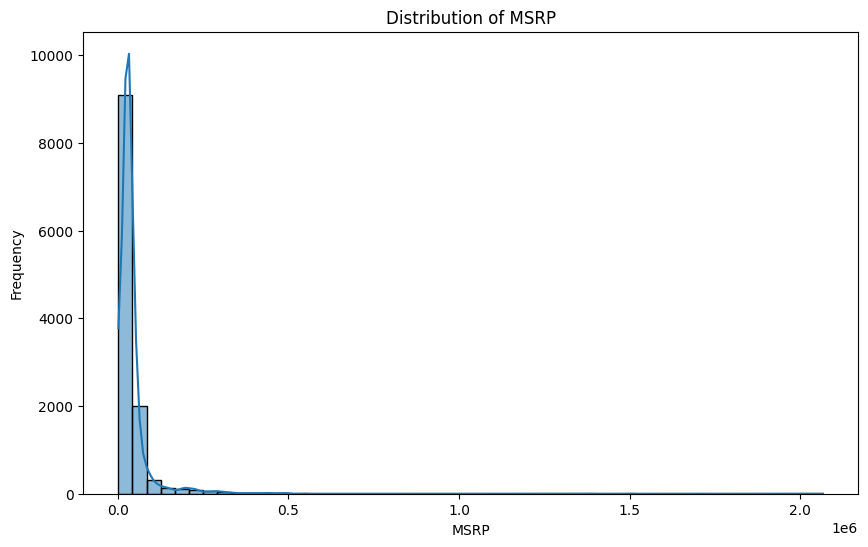


MSRP statistics:
count    1.191400e+04
mean     4.059474e+04
std      6.010910e+04
min      2.000000e+03
25%      2.100000e+04
50%      2.999500e+04
75%      4.223125e+04
max      2.065902e+06
Name: msrp, dtype: float64


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Column-wise Statistics ---")
for col in df.columns:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    if df[col].dtype == 'object':
        print(f"Sample values: {df[col].value_counts().head(5).index.tolist()}")
    else:
        print(f"Min: {df[col].min()}, Max: {df[col].max()}, Mean: {df[col].mean():.2f}")

print("\n--- Price Distribution (MSRP) ---")
plt.figure(figsize=(10, 6))
sns.histplot(df['msrp'], bins=50, kde=True)
plt.title('Distribution of MSRP')
plt.xlabel('MSRP')
plt.ylabel('Frequency')
plt.show()

print("\nMSRP statistics:")
print(df['msrp'].describe())